# MASTER US — Training & Analysis (Daily Alpha158)

All-in-one notebook: **walk-forward training** + **IC / RankIC / portfolio PnL**

**Data**: `data/spx_stock_data.csv` (WRDS CRSP daily) → Alpha158 (158) + market gate (63) + 5-day forward label

**Setup**: 10-year training / refit every 2 years (2000, 2002, …, 2024) / lookback T=8 **trading days**

**Workflow**:
1. Data prep (`RUN_DATA_PREP=True`: download indices + build panel)
2. Walk-forward training
3. IC, Rank IC, long-short PnL, Sharpe, CAPM

> Use a Conda env with `torch` installed; set `GPU_ID = 0` when a GPU is available.

In [ ]:
# ============ Training parameters ============
REFIT_YEARS = list(range(2000, 2025, 2))  # every 2 years: 2000..2024
SEED = 0
GPU_ID = 0                         # GPU index; -1 forces CPU
SMOKE_TEST = False                 # True: run only 2 epochs per fold
RUN_DATA_PREP = False              # True: re-download market data and rebuild panel
SKIP_TRAINING = True              # True: skip training and analyze saved predictions
RETRAIN = False                     # True: clear old outputs and retrain
N_EPOCH_OVERRIDE = None            # None uses config default (40)
EARLY_STOP_PATIENCE = 10           # stop if validation metric does not improve for N epochs
EARLY_STOP_METRIC = "IC"           # early-stop metric: "IC" or "RIC"
TRADE_FREQ = 5                     # rebalance frequency (trading days); should match LABEL_FORWARD_DAYS

SLIPPAGE = 0.0001

# ============ Portfolio analysis parameters ============
TOP_PCT = 0.1                     # long top 10%
BOTTOM_PCT = 0.1                  # short bottom 10%
MIN_STOCKS = 20                    # minimum stocks per rebalance date

In [8]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

ROOT = Path(".").resolve()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import (
    BETA, D_FEAT, D_MODEL, DROPOUT, EARLY_STOP_METRIC, EARLY_STOP_PATIENCE,
    GATE_INPUT_END, GATE_INPUT_START,
    LABEL_COL, LABEL_FORWARD_DAYS, LR, MARKET_FEATURES_CSV, MASTER_PANEL_PARQUET,
    N_EPOCH, OUTPUT_DIR, TRAIN_STOP_LOSS_THRED, T_NHEAD, S_NHEAD,
)
from scripts.run_walkforward import run_fold
from scripts.eval_utils import build_eval_frame, calc_ic_series, verify_saved_ic

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)

PRED_PATH = OUTPUT_DIR / "predictions.parquet"
METRICS_PATH = OUTPUT_DIR / "metrics_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

print(f"Project root: {ROOT}")
print(f"Panel path:   {MASTER_PANEL_PARQUET}")

Project root: C:\Users\Lenovo\Desktop\MASTER_SPX
Panel path:   C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet


## 1. Data preparation

In [9]:
if RUN_DATA_PREP:
    import subprocess
    for script in [
        "scripts/download_market_data.py",
        "scripts/build_market_features.py",
        "scripts/build_master_panel.py",
    ]:
        print("Running", script)
        subprocess.check_call([sys.executable, str(ROOT / script)])
else:
    if MASTER_PANEL_PARQUET.exists():
        print(f"Panel exists: {MASTER_PANEL_PARQUET}")
    else:
        raise FileNotFoundError(
            f"Missing {MASTER_PANEL_PARQUET}. Set RUN_DATA_PREP=True or run data scripts first."
        )

Panel exists: C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet


## 2. GPU / environment check

In [10]:
if GPU_ID >= 0 and torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(GPU_ID)} (cuda:{GPU_ID})")
    gpu = GPU_ID
elif GPU_ID >= 0:
    print("WARNING: CUDA not available, falling back to CPU.")
    print("Install CUDA PyTorch: pip install torch --index-url https://download.pytorch.org/whl/cu124")
    gpu = 0
else:
    print("Using CPU (GPU_ID=-1)")
    gpu = 0

n_epoch = 2 if SMOKE_TEST else (N_EPOCH_OVERRIDE or N_EPOCH)
print(f"Folds: {REFIT_YEARS} | max epochs per fold: {n_epoch}")
print(f"Early stop: monitor {EARLY_STOP_METRIC}, patience={EARLY_STOP_PATIENCE}")

Using GPU: NVIDIA GeForce GTX 1650 (cuda:0)
Folds: [2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024] | max epochs per fold: 40
Early stop: monitor IC, patience=10


## 3. Load data & training helpers

In [11]:
import pyarrow.parquet as pq

meta = pq.read_metadata(MASTER_PANEL_PARQUET)
print(f"Panel parquet: {MASTER_PANEL_PARQUET}")
print(f"Rows: {meta.num_rows:,} | Cols: {meta.num_columns}")
print("Training reads per-fold slices only (no full panel load).")
print("Tip: run one fold at a time, e.g. REFIT_YEARS = [2000]")

Panel parquet: C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet
Rows: 4,510,308 | Cols: 225
Training reads per-fold slices only (no full panel load).
Tip: run one fold at a time, e.g. REFIT_YEARS = [2000]


## 4. Walk-forward training

The first fold takes about **1–2 minutes** for data prep, then epoch progress bars appear. A full 3-fold run may take **several hours** depending on GPU/CPU.

**Flags**:
- `SKIP_TRAINING=True`: skip training and load saved results for analysis
- `RETRAIN=True`: clear old outputs and retrain from scratch (predictions and labels saved together)
- After training, saved IC is checked against recomputed analysis IC

In [ ]:
import shutil


def clean_outputs():
    """Remove stale predictions/metrics/models before a fresh run."""
    for path in (PRED_PATH, METRICS_PATH):
        if path.exists():
            path.unlink()
            print(f"Removed {path}")
    models_dir = OUTPUT_DIR / "models"
    if models_dir.exists():
        shutil.rmtree(models_dir)
        print(f"Removed {models_dir}")
    models_dir.mkdir(parents=True, exist_ok=True)


def load_saved_results():
    if not PRED_PATH.exists():
        raise FileNotFoundError(f"Not found: {PRED_PATH}. Set SKIP_TRAINING=False to train first.")
    if not METRICS_PATH.exists():
        raise FileNotFoundError(f"Not found: {METRICS_PATH}. Set SKIP_TRAINING=False to train first.")
    pred_df = pd.read_parquet(PRED_PATH)
    metrics_df = pd.read_csv(METRICS_PATH)
    if LABEL_COL not in pred_df.columns:
        raise ValueError(
            f"Saved predictions missing {LABEL_COL}. Run with RETRAIN=True to regenerate."
        )
    return pred_df, metrics_df


def save_results(pred_df, metrics_df):
    pred_df.to_parquet(PRED_PATH)
    metrics_df.to_csv(METRICS_PATH, index=False)
    print(f"Saved predictions -> {PRED_PATH}")
    print(f"Saved metrics     -> {METRICS_PATH}")
    print(f"Saved models      -> {OUTPUT_DIR / 'models'}")


if SKIP_TRAINING:
    print("SKIP_TRAINING=True: loading saved results...")
    pred_df, metrics_df = load_saved_results()
    display(metrics_df)
    display(verify_saved_ic(pred_df, metrics_df))
else:
    if RETRAIN:
        print("RETRAIN=True: cleaning old outputs and training from scratch...")
        clean_outputs()
    else:
        print("RETRAIN=False: continuing training (will overwrite outputs each fold)...")

    all_preds = []
    metrics_rows = []

    print("First fold data prep takes ~1-2 min before epoch bar appears...")
    for year in tqdm(REFIT_YEARS, desc="walk-forward folds"):
        preds, metrics = run_fold(
            MASTER_PANEL_PARQUET,
            year,
            seed=SEED,
            n_epoch=n_epoch,
            gpu=gpu,
            smoke=SMOKE_TEST,
        )
        all_preds.append(preds)
        metrics_rows.append({"refit_year": year, **metrics})

        pred_df = pd.concat(all_preds)
        metrics_df = pd.DataFrame(metrics_rows)
        save_results(pred_df, metrics_df)
        print(f"  [fold {year} done, checkpoint saved]")

    print("\n=== Per-fold OOS ===")
    display(metrics_df)
    print("\n=== Mean OOS ===")
    display(metrics_df.mean(numeric_only=True))
    print("\n=== IC consistency check (saved vs recomputed) ===")
    display(verify_saved_ic(pred_df, metrics_df))

RETRAIN=False: continuing training (will overwrite outputs each fold)...
First fold data prep takes ~1-2 min before epoch bar appears...


walk-forward folds:   0%|          | 0/13 [00:00<?, ?it/s]


[fold 2000] Computing fold dates (datetime only) ...
[fold 2000] Loading train/val slice: 1989-11-03 -> 1999-12-31 ...


## 5. Analysis helpers

In [ ]:
def long_short_pnl(
    df,
    top_pct=TOP_PCT,
    bottom_pct=BOTTOM_PCT,
    min_stocks=MIN_STOCKS,
    rebalance_days=TRADE_FREQ,
    label_clip=1.0,
    slippage=SLIPPAGE,
) -> pd.DataFrame:
    """Long-short PnL with Portfolio Turnover calculation: rebalance every `rebalance_days` trading days.

    Label is the forward return (representing LABEL_FORWARD_DAYS); each rebalance
    date uses the model's predictions on that date to select stocks.
    """
    all_dates = sorted(df.index.get_level_values("datetime").unique())
    rebalance_dates = all_dates[::rebalance_days]

    # Pre-collect selected instruments and their returns at each rebalance date
    rebalance_info = []
    for dt in rebalance_dates:
        try:
            g = df.xs(dt, level="datetime")
        except KeyError:
            continue
        n = len(g)
        if n < min_stocks:
            continue
        k_top = max(1, int(np.floor(n * top_pct)))
        k_bot = max(1, int(np.floor(n * bottom_pct)))
        g = g.sort_values("pred", ascending=False)
        
        longs = g.head(k_top)
        shorts = g.tail(k_bot)
        
        rebalance_info.append({
            "datetime": dt,
            "longs_series": longs[LABEL_COL].clip(-label_clip, label_clip),
            "shorts_series": shorts[LABEL_COL].clip(-label_clip, label_clip),
            "longs_set": set(longs.index),
            "shorts_set": set(shorts.index),
            "n": n,
            "k_top": k_top,
            "k_bot": k_bot,
        })

    rows = []
    for p in range(len(rebalance_info)):
        info = rebalance_info[p]
        dt = info["datetime"]
        longs_series = info["longs_series"]
        shorts_series = info["shorts_series"]
        longs_set = info["longs_set"]
        shorts_set = info["shorts_set"]
        n = info["n"]
        k_top = info["k_top"]
        k_bot = info["k_bot"]
        
        prev_longs_set = rebalance_info[p - 1]["longs_set"] if p > 0 else set()
        prev_shorts_set = rebalance_info[p - 1]["shorts_set"] if p > 0 else set()
        
        next_longs_set = rebalance_info[p + 1]["longs_set"] if p + 1 < len(rebalance_info) else set()
        next_shorts_set = rebalance_info[p + 1]["shorts_set"] if p + 1 < len(rebalance_info) else set()
        
        # Calculate Turnover (one-sided) as 1.0 - overlap_ratio for each leg
        if p > 0:
            long_to = 1.0 - (len(longs_set.intersection(prev_longs_set)) / k_top)
            short_to = 1.0 - (len(shorts_set.intersection(prev_shorts_set)) / k_bot)
            port_to = (long_to + short_to) / 2.0
        else:
            port_to = np.nan
            
        # Calculate per-stock net return in long leg
        long_rets = []
        for stock_id, r_raw in longs_series.items():
            s_buy = 0.0 if stock_id in prev_longs_set else (slippage if slippage is not None else 0.0)
            s_sell = 0.0 if stock_id in next_longs_set else (slippage if slippage is not None else 0.0)
            if s_buy > 0.0 or s_sell > 0.0:
                r_net = (1 + r_raw) * (1 - s_sell) / (1 + s_buy) - 1
            else:
                r_net = r_raw
            long_rets.append(r_net)
            
        # Calculate per-stock net return in short leg
        short_rets = []
        bottom_rets = []
        for stock_id, r_raw in shorts_series.items():
            s_sell = 0.0 if stock_id in prev_shorts_set else (slippage if slippage is not None else 0.0)
            s_buy = 0.0 if stock_id in next_shorts_set else (slippage if slippage is not None else 0.0)
            if s_sell > 0.0 or s_buy > 0.0:
                r_net_short = (1 - s_sell) - (1 + r_raw) * (1 + s_buy)
            else:
                r_net_short = -r_raw
            short_rets.append(r_net_short)
            bottom_rets.append(r_raw)
            
        long_ret = np.mean(long_rets) if len(long_rets) > 0 else np.nan
        short_ret = np.mean(short_rets) if len(short_rets) > 0 else np.nan
        bottom_ret = np.mean(bottom_rets) if len(bottom_rets) > 0 else np.nan
        
        rows.append({
            "datetime": dt,
            "long": long_ret,
            "bottom_ret": bottom_ret,
            "short": short_ret,
            "ls": long_ret + short_ret,
            "n": n,
            "k_top": k_top,
            "k_bot": k_bot,
            "portfolio_turnover": port_to,
        })

    pnl = pd.DataFrame(rows).set_index("datetime").sort_index()
    pnl["cum_ls"] = pnl["ls"].cumsum()
    pnl["cum_long"] = pnl["long"].cumsum()
    pnl["cum_short"] = pnl["short"].cumsum()
    return pnl


def portfolio_stats(
    period_rets: pd.Series,
    periods_per_year: float | None = None,
    hold_days: int = LABEL_FORWARD_DAYS,
) -> pd.Series:
    """Annual return and Sharpe from per-period returns (simple interest).

    Each period return represents a `hold_days`-day return.
    `periods_per_year` should be 252 / hold_days (e.g. 252/5 = 50.4 for 5-day returns).
    Annual return = mean(period_return) × periods_per_year.
    """
    if periods_per_year is None:
        periods_per_year = 252.0 / hold_days
    r = period_rets.dropna()
    if len(r) == 0 or r.std() == 0:
        return pd.Series({"ann_return": np.nan, "sharpe": np.nan, "n_periods": len(r)})
    ann_return = r.mean() * periods_per_year
    sharpe = r.mean() / r.std() * np.sqrt(periods_per_year)
    return pd.Series({"ann_return": ann_return, "sharpe": sharpe, "n_periods": len(r)})


def load_spx_daily_return(market_path=MARKET_FEATURES_CSV) -> pd.Series:
    """Load SPX daily return, indexed by calendar date."""
    mkt = pd.read_csv(market_path, index_col=0, parse_dates=True)
    spx = mkt["SPX_ret_1d"].copy()
    spx.index = pd.to_datetime(spx.index).normalize()
    return spx.rename("spx")


def load_spx_holding_return(
    rebalance_dates,
    forward_days: int = LABEL_FORWARD_DAYS,
    market_path=MARKET_FEATURES_CSV,
) -> pd.Series:
    """SPX return over the same holding window as label: close[t+5]/close[t]-1."""
    spx = load_spx_daily_return(market_path)
    cal = spx.index.sort_values()
    out = {}
    for dt in rebalance_dates:
        t = pd.Timestamp(dt).normalize()
        if t not in cal:
            continue
        idx = cal.get_loc(t)
        if idx + forward_days >= len(cal):
            continue
        # close[t+5]/close[t]-1 = prod(1+ret) for days t+1..t+5
        period_ret = (1 + spx.iloc[idx + 1 : idx + forward_days + 1]).prod() - 1
        out[t] = period_ret
    return pd.Series(out, name="spx")


def capm_alpha_beta(
    portfolio_rets: pd.Series,
    market_rets: pd.Series,
    periods_per_year: float | None = None,
    hold_days: int = LABEL_FORWARD_DAYS,
) -> pd.Series:
    """CAPM on per-period returns (aligned with hold_days-day holding periods).

    alpha_annual = alpha_period × periods_per_year (simple interest).
    """
    if periods_per_year is None:
        periods_per_year = 252.0 / hold_days
    port = portfolio_rets.copy()
    port.index = pd.to_datetime(port.index).normalize()
    mkt = market_rets.copy()
    mkt.index = pd.to_datetime(mkt.index).normalize()
    df = pd.concat([port.rename("port"), mkt], axis=1).dropna()
    if len(df) < 2 or df["spx"].std() == 0:
        return pd.Series({
            "corr_spx": np.nan, "beta": np.nan,
            "alpha_period": np.nan, "alpha_annual": np.nan, "n_periods": len(df),
        })
    p, m = df["port"], df["spx"]
    corr = p.corr(m)
    beta = corr * p.std() / m.std()
    alpha_period = p.mean() - beta * m.mean()
    return pd.Series({
        "corr_spx": corr, "beta": beta,
        "alpha_period": alpha_period,
        "alpha_annual": alpha_period * periods_per_year,
        "n_periods": len(df),
    })

In [ ]:
eval_df = build_eval_frame(pred_df)
ic_df = calc_ic_series(eval_df)
pnl_df = long_short_pnl(eval_df)

print(f"Samples: {len(eval_df):,}")
print(f"Date range: {eval_df.index.get_level_values(0).min().date()} -> {eval_df.index.get_level_values(0).max().date()}")
print(f"Trading days: {len(ic_df)}")
print("\nIC summary:")
print(f"  Mean IC:      {ic_df['IC'].mean():.4f}")
print(f"  ICIR:         {ic_df['IC'].mean() / ic_df['IC'].std():.4f}")
print(f"  Mean RankIC:  {ic_df['RankIC'].mean():.4f}")
print(f"  RankICIR:     {ic_df['RankIC'].mean() / ic_df['RankIC'].std():.4f}")
# periods/year = 252 / LABEL_FORWARD_DAYS (each period return is the label's N-day forward return)
PERIODS_PER_YEAR = 252.0 / LABEL_FORWARD_DAYS

print(f"Rebalance: every {TRADE_FREQ} trading days | Label: {LABEL_FORWARD_DAYS}-day forward | periods/year = {PERIODS_PER_YEAR:.1f}")
print(f"Portfolio periods: {len(pnl_df)}")

print("\nLong-Short portfolio (Top/Bottom 10%):")
ls_stats = portfolio_stats(pnl_df["ls"])
long_stats = portfolio_stats(pnl_df["long"])
short_stats = portfolio_stats(pnl_df["short"])
print(f"  Mean {LABEL_FORWARD_DAYS}-day return: {pnl_df['ls'].mean():.4f}")
print(f"  Total cum return:  {pnl_df['cum_ls'].iloc[-1]:.4f}")
print(f"  Annual return:     {ls_stats['ann_return']:.2%}")
print(f"  Sharpe ratio:      {ls_stats['sharpe']:.2f}")

print("\nLong-only:")
print(f"  Annual return: {long_stats['ann_return']:.2%} | Sharpe: {long_stats['sharpe']:.2f}")
print("Short-only:")
print(f"  Annual return: {short_stats['ann_return']:.2%} | Sharpe: {short_stats['sharpe']:.2f}")

stats_df = pd.DataFrame({
    "Long-Short": portfolio_stats(pnl_df["ls"]),
    "Long-only": portfolio_stats(pnl_df["long"]),
    "Short-only": portfolio_stats(pnl_df["short"]),
}).T[["ann_return", "sharpe", "n_periods"]]
print("\nPortfolio stats summary:")
display(stats_df.style.format({"ann_return": "{:.2%}", "sharpe": "{:.2f}", "n_periods": "{:.0f}"}))

spx_rets = load_spx_holding_return(pnl_df.index)
capm_df = pd.DataFrame({
    "Long-Short": capm_alpha_beta(pnl_df["ls"], spx_rets),
    "Long-only": capm_alpha_beta(pnl_df["long"], spx_rets),
    "Short-only": capm_alpha_beta(pnl_df["short"], spx_rets),
}).T[["corr_spx", "beta", "alpha_period", "alpha_annual", "n_periods"]]
print(f"\nCAPM vs SPX ({LABEL_FORWARD_DAYS}-day holding return vs SPX {LABEL_FORWARD_DAYS}-day return):")
print("  beta = corr(port, SPX) * std(port) / std(SPX)")
print("  alpha_period = mean(port) - beta * mean(SPX)")
print("  alpha_annual = alpha_period × periods_per_year  (simple interest)")
display(capm_df.style.format({
    "corr_spx": "{:.3f}",
    "beta": "{:.3f}",
    "alpha_period": "{:.4f}",
    "alpha_annual": "{:.2%}",
    "n_periods": "{:.0f}",
}))

ic_df.head()

Samples: 3,245,849
Date range: 2000-01-03 -> 2025-12-23
Trading days: 6534

IC summary:
  Mean IC:      0.0260
  ICIR:         0.4195
  Mean RankIC:  0.0244
  RankICIR:     0.4980
Rebalance: every 5 trading days | Label: 5-day forward | periods/year = 50.4
Portfolio periods: 1307

Long-Short portfolio (Top/Bottom 10%):
  Mean 5-day return: 0.0053
  Total cum return:  6.9264
  Annual return:     26.71%
  Sharpe ratio:      2.69

Long-only:
  Annual return: 26.87% | Sharpe: 3.85
Short-only:
  Annual return: -0.16% | Sharpe: -0.03

Portfolio stats summary:


,ann_return,sharpe,n_periods
Long-Short,26.71%,2.69,1307
Long-only,26.87%,3.85,1307
Short-only,-0.16%,-0.03,1307



CAPM vs SPX (5-day holding return vs SPX 5-day return):
  beta = corr(port, SPX) * std(port) / std(SPX)
  alpha_period = mean(port) - beta * mean(SPX)
  alpha_annual = alpha_period × periods_per_year  (simple interest)


,corr_spx,beta,alpha_period,alpha_annual,n_periods
Long-Short,-0.049,-0.027,0.0053,26.92%,1307
Long-only,-0.023,-0.009,0.0053,26.94%,1307
Short-only,-0.051,-0.018,-0.0000,-0.03%,1307


,IC,RankIC,n,cum_IC,cum_RankIC
datetime,,,,,
2000-01-03,0.109537,0.082663,496.0,0.109537,0.082663
2000-01-04,0.022063,0.014040,496.0,0.131600,0.096703
2000-01-05,0.130960,0.075572,496.0,0.262560,0.172275
2000-01-06,0.073626,0.033277,496.0,0.336186,0.205553
2000-01-07,-0.003662,-0.023629,496.0,0.332524,0.181924


## 6. IC & Cumulative IC

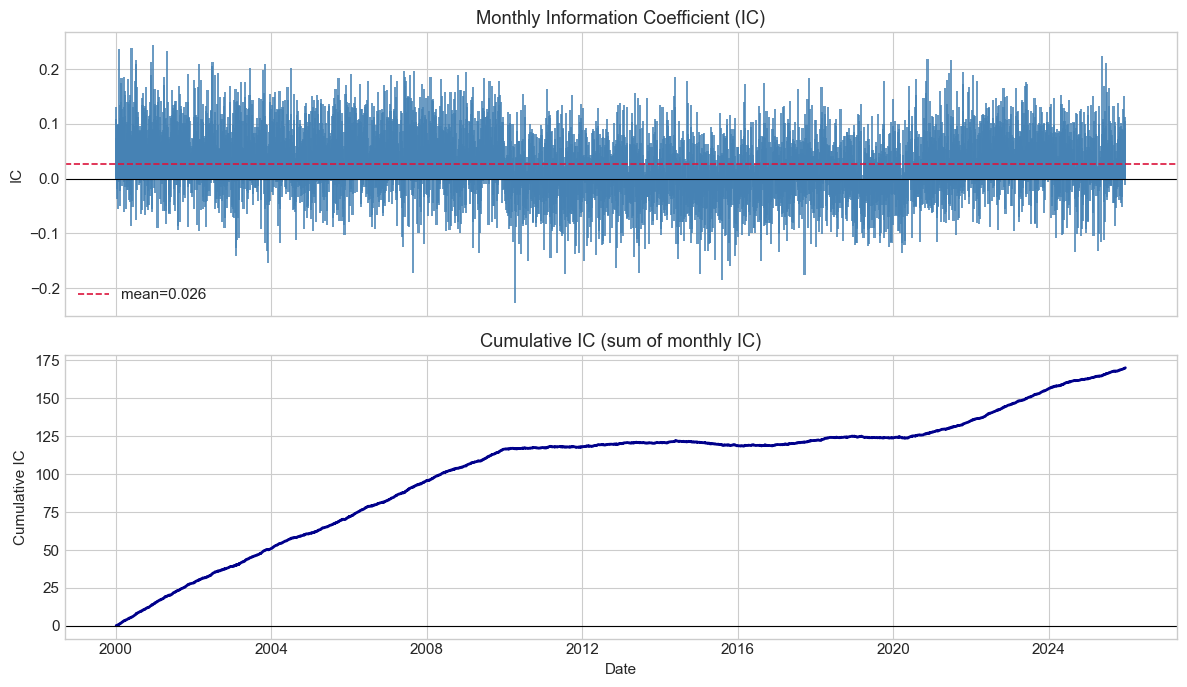

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(ic_df.index, ic_df["IC"], width=20, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(ic_df["IC"].mean(), color="crimson", ls="--", lw=1.2, label=f"mean={ic_df['IC'].mean():.3f}")
axes[0].set_ylabel("IC")
axes[0].set_title("Monthly Information Coefficient (IC)")
axes[0].legend()

axes[1].plot(ic_df.index, ic_df["cum_IC"], color="darkblue", lw=2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative IC")
axes[1].set_title("Cumulative IC (sum of monthly IC)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 7. Rank IC & Cumulative Rank IC

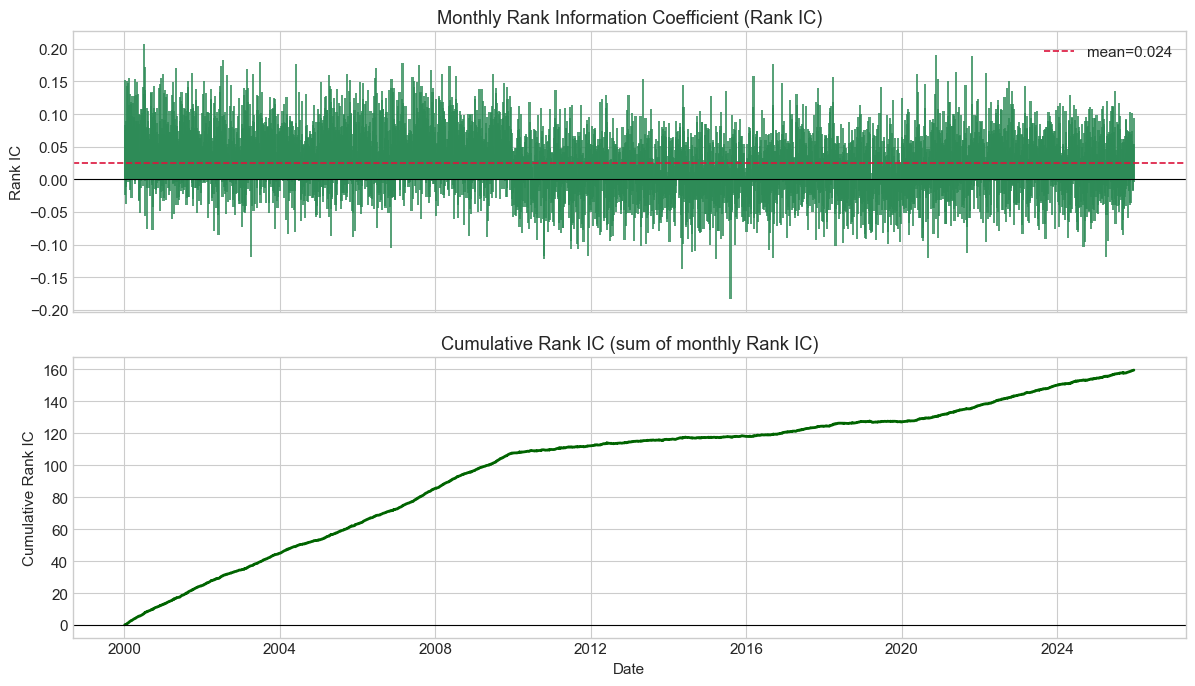

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(ic_df.index, ic_df["RankIC"], width=20, color="seagreen", alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(ic_df["RankIC"].mean(), color="crimson", ls="--", lw=1.2, label=f"mean={ic_df['RankIC'].mean():.3f}")
axes[0].set_ylabel("Rank IC")
axes[0].set_title("Monthly Rank Information Coefficient (Rank IC)")
axes[0].legend()

axes[1].plot(ic_df.index, ic_df["cum_RankIC"], color="darkgreen", lw=2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative Rank IC")
axes[1].set_title("Cumulative Rank IC (sum of monthly Rank IC)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 8. Portfolio PnL (Long Top 10% / Short Bottom 10%)

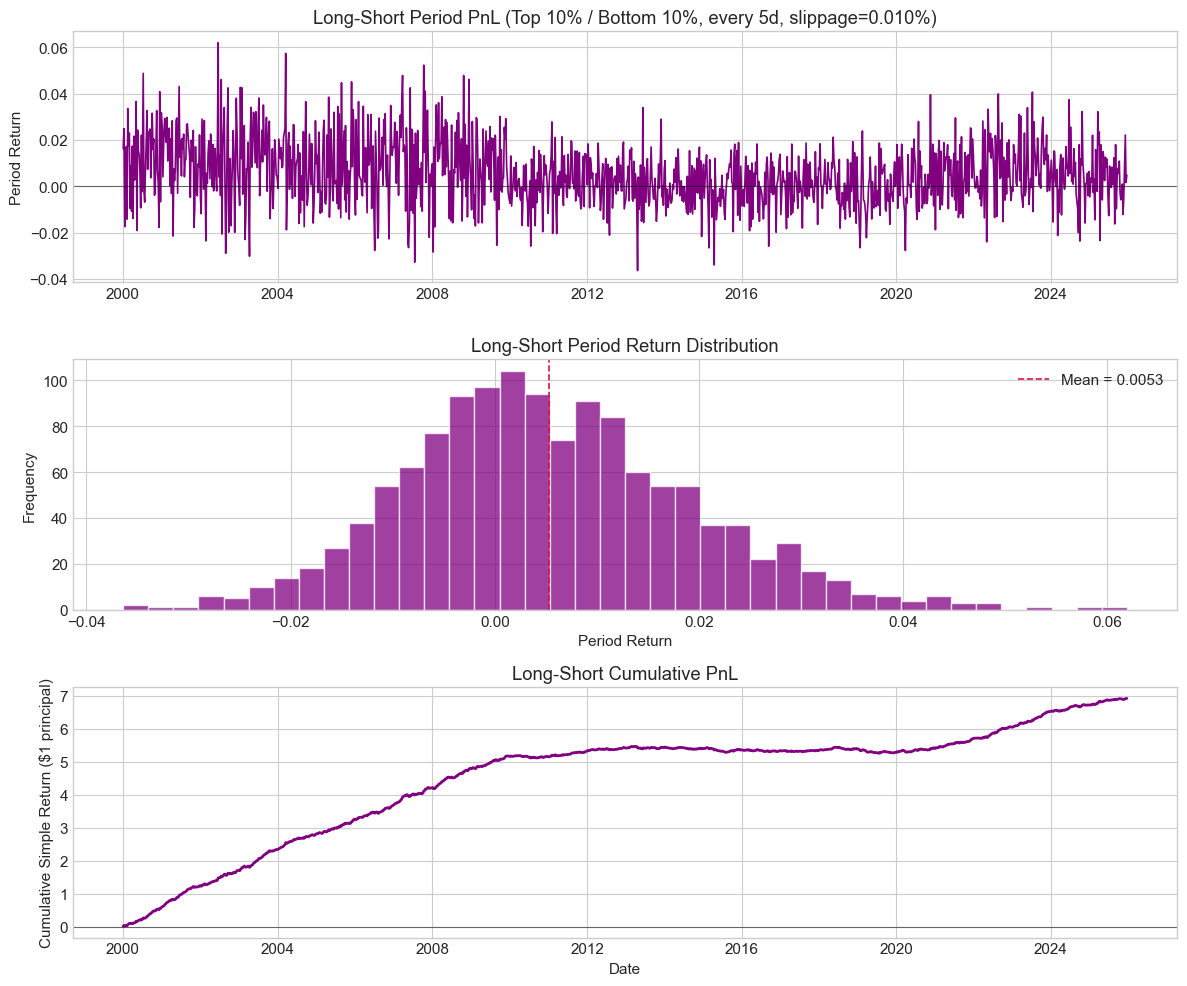

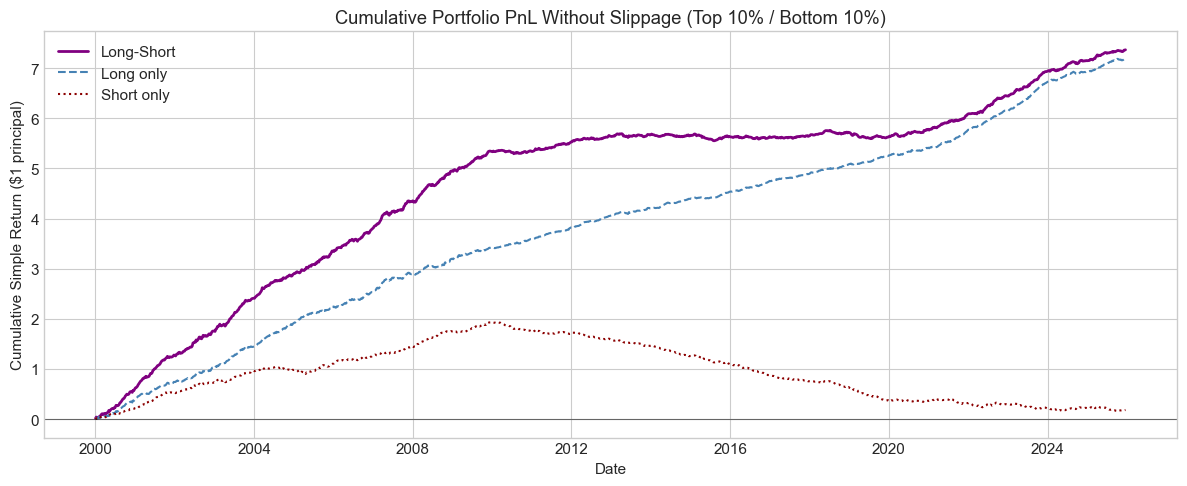

In [ ]:
# Figure 1: Long-short portfolio — period PnL, return distribution, cumulative PnL
slip_note = f", slippage={SLIPPAGE:.3%}" if SLIPPAGE else ""
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(pnl_df.index, pnl_df["ls"], color="purple", lw=1.2)
axes[0].axhline(0, color="black", lw=0.8, alpha=0.5)
axes[0].set_ylabel("Period Return")
axes[0].set_title(
    f"Long-Short Period PnL (Top {TOP_PCT:.0%} / Bottom {BOTTOM_PCT:.0%}, "
    f"every {TRADE_FREQ}d{slip_note})"
)

ls_rets = pnl_df["ls"].dropna()
axes[1].hist(ls_rets, bins=40, color="purple", alpha=0.75, edgecolor="white")
axes[1].axvline(ls_rets.mean(), color="crimson", ls="--", lw=1.2, label=f"Mean = {ls_rets.mean():.4f}")
axes[1].set_xlabel("Period Return")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Long-Short Period Return Distribution")
axes[1].legend()

axes[2].plot(pnl_df.index, pnl_df["cum_ls"], color="purple", lw=2)
axes[2].axhline(0, color="black", lw=0.8, alpha=0.5)
axes[2].set_ylabel("Cumulative Simple Return ($1 principal)")
axes[2].set_xlabel("Date")
axes[2].set_title("Long-Short Cumulative PnL")

plt.tight_layout()
plt.show()

# Figure 2: Cumulative PnL without slippage — long-short, long-only, short-only
pnl_no_slip = long_short_pnl(eval_df, slippage=0.0)

fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(pnl_no_slip.index, pnl_no_slip["cum_ls"], label="Long-Short", color="purple", lw=2)
ax2.plot(pnl_no_slip.index, pnl_no_slip["cum_long"], label="Long only", color="steelblue", lw=1.5, ls="--")
ax2.plot(pnl_no_slip.index, pnl_no_slip["cum_short"], label="Short only", color="darkred", lw=1.5, ls=":")
ax2.axhline(0, color="black", lw=0.8, alpha=0.5)
ax2.set_ylabel("Cumulative Simple Return ($1 principal)")
ax2.set_xlabel("Date")
ax2.set_title(
    f"Cumulative Portfolio PnL Without Slippage "
    f"(Top {TOP_PCT:.0%} / Bottom {BOTTOM_PCT:.0%})"
)
ax2.legend()
plt.tight_layout()
plt.show()

## 9. CAPM scatter (long-short vs SPX) & portfolio turnover

Additional analysis plots:
1. **Long-short 5-day return vs SPX 5-day return CAPM scatter**: OLS fit where the slope is **beta** and the intercept is per-period **alpha**.
2. **Portfolio rebalance turnover time series**: turnover at each rebalance date helps assess trading friction and liquidity costs.

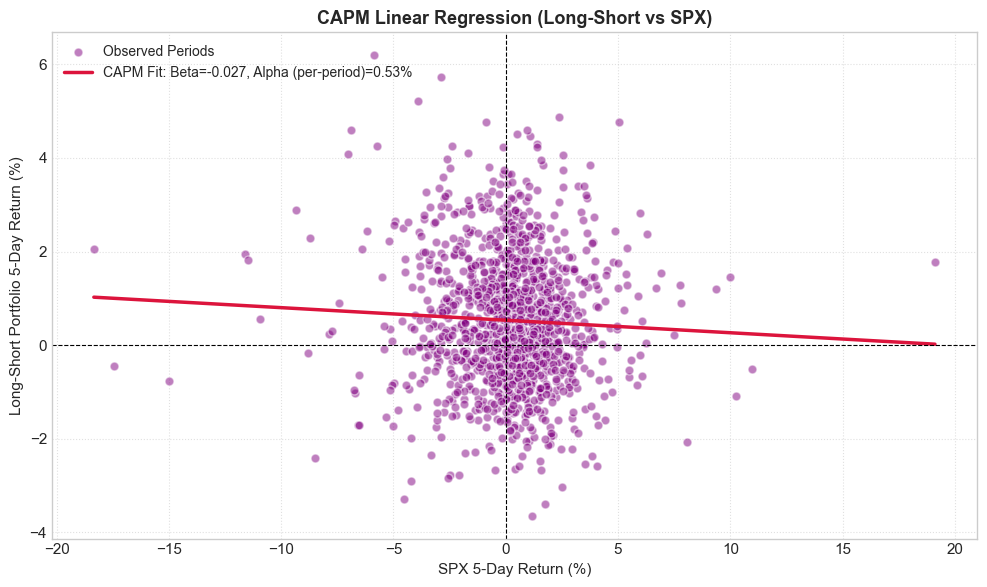

In [ ]:
# CAPM scatter: portfolio return vs SPX return
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Align long-short portfolio returns with SPX holding-period returns
aligned_df = pd.concat([pnl_df["ls"].rename("port_ls"), spx_rets.rename("spx")], axis=1).dropna()

# OLS slope (beta) and intercept (alpha per period)
slope, intercept, r_value, p_value, std_err = linregress(aligned_df["spx"], aligned_df["port_ls"])

plt.figure(figsize=(10, 6))

# Scatter plot and OLS fit line
plt.scatter(aligned_df["spx"] * 100, aligned_df["port_ls"] * 100, color="purple", alpha=0.5, edgecolors="white", s=40, label="Observed Periods")
x_range = np.linspace(aligned_df["spx"].min(), aligned_df["spx"].max(), 100)
plt.plot(x_range * 100, (slope * x_range + intercept) * 100, color="crimson", lw=2.5, 
         label=f"CAPM Fit: Beta={slope:.3f}, Alpha (per-period)={intercept:.2%}")
plt.axhline(0, color="black", ls="--", lw=0.8)
plt.axvline(0, color="black", ls="--", lw=0.8)
plt.xlabel("SPX 5-Day Return (%)", fontsize=11)
plt.ylabel("Long-Short Portfolio 5-Day Return (%)", fontsize=11)
plt.title("CAPM Linear Regression (Long-Short vs SPX)", fontsize=13, fontweight="bold")
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, ls=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 10. Portfolio turnover at rebalance dates

Portfolio turnover of the long-short book at each rebalance date $t$.
Definitions:
* **One-sided leg turnover** at each rebalance date (non-overlap with the previous holdings):
  $$TO_{long, t} = 1 - \frac{|Long_t \cap Long_{t-1}|}{k_{top}}$$
  $$TO_{short, t} = 1 - \frac{|Short_t \cap Short_{t-1}|}{k_{bot}}$$
* **Portfolio turnover** (average of the two legs):
  $$TO_t = \frac{TO_{long, t} + TO_{short, t}}{2}$$

High turnover increases trading friction; the rolling mean highlights stability of rebalancing over time.

Plotting portfolio rebalance turnover rate...


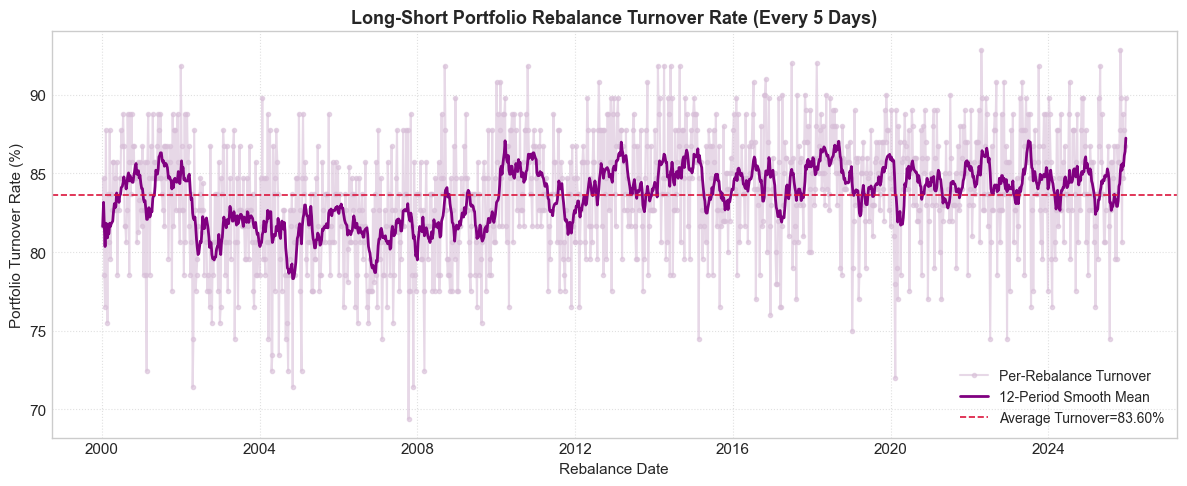

In [ ]:
# Plot portfolio turnover at rebalance dates
import matplotlib.pyplot as plt
import pandas as pd

print("Plotting portfolio rebalance turnover rate...")
if "portfolio_turnover" in pnl_df.columns:
    # turnover time series
    to_series = pnl_df["portfolio_turnover"].dropna()
    # 12-period rolling mean (~2-3 months of rebalance periods)
    roll_to = to_series.rolling(12, min_periods=1).mean()

    plt.figure(figsize=(12, 5))
    # per-rebalance turnover and rolling mean
    plt.plot(to_series.index, to_series * 100, color="thistle", marker="o", markersize=3, alpha=0.6, label="Per-Rebalance Turnover")
    plt.plot(roll_to.index, roll_to * 100, color="purple", lw=2, label="12-Period Smooth Mean")
    
    plt.ylabel("Portfolio Turnover Rate (%)", fontsize=11)
    plt.xlabel("Rebalance Date", fontsize=11)
    plt.title(f"Long-Short Portfolio Rebalance Turnover Rate (Every {LABEL_FORWARD_DAYS} Days)", fontsize=13, fontweight="bold")
    
    # average turnover reference line
    mean_to = to_series.mean()
    plt.axhline(mean_to * 100, color="crimson", ls="--", lw=1.2, label=f"Average Turnover={mean_to:.2%}")
    
    plt.legend(fontsize=10, loc="lower right")
    plt.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'portfolio_turnover' not found in pnl_df. Please re-run Section 5 Cells to compute it.")